In [1]:
# ============================================================
# 1. Importación de librerías
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(42)

In [2]:
# ============================================================
# 2. Configuración general del dataset sintético
# ============================================================

N = 5000  # número aproximado de registros sintéticos

administraciones_zonales = [
    "Eloy Alfaro",
    "Manuela Sáenz",
    "Eugenio Espejo",
    "La Delicia",
    "Quitumbe",
    "Calderón",
    "Tumbaco",
    "Los Chillos",
    "Aeropuerto"
]

tipos_incidente = [
    "Robo a personas",
    "Robo de vehículos",
    "Robo de autopartes",
    "Alteración del orden público",
    "Emergencia comunitaria",
    "Vandalismo",
    "Incidente de tránsito"
]

In [3]:
# ============================================================
# 3. Pesos sintéticos por zona, tipo, hora y día
# ============================================================
# Estos pesos NO representan datos reales exactos.
# Sirven para simular que ciertos contextos tienen mayor demanda operativa.

pesos_zona = {
    "Eloy Alfaro": 1.35,
    "Manuela Sáenz": 1.25,
    "Eugenio Espejo": 1.15,
    "La Delicia": 1.00,
    "Quitumbe": 1.20,
    "Calderón": 0.95,
    "Tumbaco": 0.75,
    "Los Chillos": 0.85,
    "Aeropuerto": 0.70
}

pesos_tipo = {
    "Robo a personas": 1.35,
    "Robo de vehículos": 1.20,
    "Robo de autopartes": 1.15,
    "Alteración del orden público": 1.25,
    "Emergencia comunitaria": 0.85,
    "Vandalismo": 0.90,
    "Incidente de tránsito": 1.05
}

def obtener_franja_horaria(hora):
    if 0 <= hora <= 5:
        return "Madrugada"
    elif 6 <= hora <= 11:
        return "Mañana"
    elif 12 <= hora <= 17:
        return "Tarde"
    else:
        return "Noche"

def peso_hora(hora):
    """
    Mayor peso en horas con posible mayor demanda:
    - madrugada
    - entrada/salida laboral
    - noche
    """
    if 0 <= hora <= 4:
        return 1.25
    elif 6 <= hora <= 8:
        return 1.10
    elif 12 <= hora <= 14:
        return 1.05
    elif 17 <= hora <= 21:
        return 1.45
    else:
        return 0.90

def peso_dia(dia_semana):
    """
    Mayor peso en viernes y sábado.
    """
    if dia_semana == "viernes":
        return 1.20
    elif dia_semana == "sábado":
        return 1.30
    elif dia_semana == "domingo":
        return 1.05
    else:
        return 0.95

In [4]:
# ============================================================
# 4. Generación de variables base
# ============================================================

fecha_inicio = datetime(2025, 1, 1)
fecha_fin = datetime(2025, 12, 31)
dias_rango = (fecha_fin - fecha_inicio).days + 1

fechas = [
    fecha_inicio + timedelta(days=int(np.random.randint(0, dias_rango)))
    for _ in range(N)
]

horas = np.random.randint(0, 24, N)

zonas = np.random.choice(
    administraciones_zonales,
    size=N,
    p=[0.15, 0.13, 0.12, 0.11, 0.13, 0.10, 0.08, 0.10, 0.08]
)

tipos = np.random.choice(
    tipos_incidente,
    size=N,
    p=[0.24, 0.15, 0.14, 0.17, 0.10, 0.08, 0.12]
)

df = pd.DataFrame({
    "id_registro": range(1, N + 1),
    "fecha": fechas,
    "hora": horas,
    "administracion_zonal": zonas,
    "tipo_incidente": tipos
})

df["fecha"] = pd.to_datetime(df["fecha"])
df["mes"] = df["fecha"].dt.month
df["dia_semana_num"] = df["fecha"].dt.dayofweek

mapa_dias = {
    0: "lunes",
    1: "martes",
    2: "miércoles",
    3: "jueves",
    4: "viernes",
    5: "sábado",
    6: "domingo"
}

df["dia_semana"] = df["dia_semana_num"].map(mapa_dias)
df["franja_horaria"] = df["hora"].apply(obtener_franja_horaria)
df["es_fin_semana"] = df["dia_semana"].isin(["sábado", "domingo"]).astype(int)

df.head()

,id_registro,fecha,hora,administracion_zonal,tipo_incidente,mes,dia_semana_num,dia_semana,franja_horaria,es_fin_semana
0,1,2025-04-13,23,Manuela Sáenz,Robo de vehículos,4,6,domingo,Noche,1
1,2,2025-12-15,9,Los Chillos,Emergencia comunitaria,12,0,lunes,Mañana,0
2,3,2025-09-28,6,Quitumbe,Emergencia comunitaria,9,6,domingo,Mañana,1
3,4,2025-04-17,16,Eloy Alfaro,Incidente de tránsito,4,3,jueves,Tarde,0
4,5,2025-03-13,3,Los Chillos,Robo a personas,3,3,jueves,Madrugada,0


In [5]:
# ============================================================
# 5. Variable feriado
# ============================================================
# Lista sintética basada en feriados comunes.
# Para el proyecto académico no es necesario que sea una lista oficial completa.

feriados_simulados = pd.to_datetime([
    "2025-01-01",
    "2025-03-03",
    "2025-03-04",
    "2025-04-18",
    "2025-05-01",
    "2025-05-24",
    "2025-08-10",
    "2025-10-09",
    "2025-11-02",
    "2025-11-03",
    "2025-12-25"
])

df["es_feriado"] = df["fecha"].isin(feriados_simulados).astype(int)

df[["fecha", "dia_semana", "es_feriado"]].head()

,fecha,dia_semana,es_feriado
0,2025-04-13,domingo,0
1,2025-12-15,lunes,0
2,2025-09-28,domingo,0
3,2025-04-17,jueves,0
4,2025-03-13,jueves,0


In [6]:
# ============================================================
# 6. Simulación del conteo de incidentes
# ============================================================
# El conteo de incidentes se simula usando una distribución Poisson.
# Lambda cambia según zona, hora, día, feriado y tipo de incidente.

intensidades = []

for _, row in df.iterrows():
    base = 2.0

    w_zona = pesos_zona[row["administracion_zonal"]]
    w_tipo = pesos_tipo[row["tipo_incidente"]]
    w_hora = peso_hora(row["hora"])
    w_dia = peso_dia(row["dia_semana"])
    w_feriado = 1.20 if row["es_feriado"] == 1 else 1.00

    lambda_final = base * w_zona * w_tipo * w_hora * w_dia * w_feriado
    intensidades.append(lambda_final)

df["intensidad_esperada"] = intensidades
df["conteo_incidentes"] = np.random.poisson(lam=df["intensidad_esperada"])

df[[
    "administracion_zonal",
    "tipo_incidente",
    "hora",
    "dia_semana",
    "es_feriado",
    "intensidad_esperada",
    "conteo_incidentes"
]].head()

,administracion_zonal,tipo_incidente,hora,dia_semana,es_feriado,intensidad_esperada,conteo_incidentes
0,Manuela Sáenz,Robo de vehículos,23,domingo,0,2.835000,0
1,Los Chillos,Emergencia comunitaria,9,lunes,0,1.235475,1
2,Quitumbe,Emergencia comunitaria,6,domingo,0,2.356200,2
3,Eloy Alfaro,Incidente de tránsito,16,jueves,0,2.423925,3
4,Los Chillos,Robo a personas,3,jueves,0,2.725312,1


In [7]:
# ============================================================
# 7. Creación de variable objetivo: alta_demanda
# ============================================================
# Se define alta demanda como los bloques cuyo conteo de incidentes
# está en el 25% superior de la distribución.

umbral_alta_demanda = df["conteo_incidentes"].quantile(0.75)

df["alta_demanda"] = (df["conteo_incidentes"] >= umbral_alta_demanda).astype(int)

print("Umbral para alta demanda:", umbral_alta_demanda)
print("\nDistribución de la variable objetivo:")
print(df["alta_demanda"].value_counts())
print("\nProporción:")
print(df["alta_demanda"].value_counts(normalize=True).round(3))

Umbral para alta demanda: 4.0

Distribución de la variable objetivo:
alta_demanda
0    3307
1    1693
Name: count, dtype: int64

Proporción:
alta_demanda
0    0.661
1    0.339
Name: proportion, dtype: float64


In [8]:
  # ============================================================
# 8. Reordenar columnas del dataset
# ============================================================

columnas_ordenadas = [
    "id_registro",
    "fecha",
    "mes",
    "dia_semana",
    "dia_semana_num",
    "hora",
    "franja_horaria",
    "es_fin_semana",
    "es_feriado",
    "administracion_zonal",
    "tipo_incidente",
    "intensidad_esperada",
    "conteo_incidentes",
    "alta_demanda"
]

df = df[columnas_ordenadas]

df.head()

,id_registro,fecha,mes,dia_semana,dia_semana_num,hora,franja_horaria,es_fin_semana,es_feriado,administracion_zonal,tipo_incidente,intensidad_esperada,conteo_incidentes,alta_demanda
0,1,2025-04-13,4,domingo,6,23,Noche,1,0,Manuela Sáenz,Robo de vehículos,2.835000,0,0
1,2,2025-12-15,12,lunes,0,9,Mañana,0,0,Los Chillos,Emergencia comunitaria,1.235475,1,0
2,3,2025-09-28,9,domingo,6,6,Mañana,1,0,Quitumbe,Emergencia comunitaria,2.356200,2,0
3,4,2025-04-17,4,jueves,3,16,Tarde,0,0,Eloy Alfaro,Incidente de tránsito,2.423925,3,0
4,5,2025-03-13,3,jueves,3,3,Madrugada,0,0,Los Chillos,Robo a personas,2.725312,1,0


In [9]:
# ============================================================
# 10. Limpieza básica del dataset
# ============================================================

df_limpio = df.copy()

# 1. Eliminar duplicados
df_limpio = df_limpio.drop_duplicates()

# 2. Corregir horas fuera de rango
df_limpio = df_limpio[(df_limpio["hora"] >= 0) & (df_limpio["hora"] <= 23)]

# 3. Imputar nulos categóricos
df_limpio["administracion_zonal"] = df_limpio["administracion_zonal"].fillna("No especificado")
df_limpio["tipo_incidente"] = df_limpio["tipo_incidente"].fillna("No especificado")

# 4. Recalcular franja horaria por si hubo correcciones
df_limpio["franja_horaria"] = df_limpio["hora"].apply(obtener_franja_horaria)

# 5. Validaciones finales
print("Dimensiones del dataset limpio:", df_limpio.shape)
print("\nValores nulos después de limpieza:")
print(df_limpio.isnull().sum())
print("\nDuplicados después de limpieza:")
print(df_limpio.duplicated().sum())

Dimensiones del dataset limpio: (5000, 14)

Valores nulos después de limpieza:
id_registro             0
fecha                   0
mes                     0
dia_semana              0
dia_semana_num          0
hora                    0
franja_horaria          0
es_fin_semana           0
es_feriado              0
administracion_zonal    0
tipo_incidente          0
intensidad_esperada     0
conteo_incidentes       0
alta_demanda            0
dtype: int64

Duplicados después de limpieza:
0


In [10]:
# ============================================================
# 11. Descripción general del dataset
# ============================================================

print("Número de registros:", df_limpio.shape[0])
print("Número de variables:", df_limpio.shape[1])

display(df_limpio.head())

print("\nTipos de datos:")
display(df_limpio.dtypes)

print("\nEstadística descriptiva:")
display(df_limpio.describe())

print("\nDistribución de alta_demanda:")
display(df_limpio["alta_demanda"].value_counts(normalize=True).round(3))

Número de registros: 5000
Número de variables: 14


,id_registro,fecha,mes,dia_semana,dia_semana_num,hora,franja_horaria,es_fin_semana,es_feriado,administracion_zonal,tipo_incidente,intensidad_esperada,conteo_incidentes,alta_demanda
0,1,2025-04-13,4,domingo,6,23,Noche,1,0,Manuela Sáenz,Robo de vehículos,2.835000,0,0
1,2,2025-12-15,12,lunes,0,9,Mañana,0,0,Los Chillos,Emergencia comunitaria,1.235475,1,0
2,3,2025-09-28,9,domingo,6,6,Mañana,1,0,Quitumbe,Emergencia comunitaria,2.356200,2,0
3,4,2025-04-17,4,jueves,3,16,Tarde,0,0,Eloy Alfaro,Incidente de tránsito,2.423925,3,0
4,5,2025-03-13,3,jueves,3,3,Madrugada,0,0,Los Chillos,Robo a personas,2.725312,1,0



Tipos de datos:


,0
id_registro,int64
fecha,datetime64[ns]
mes,int32
dia_semana,object
dia_semana_num,int32
hora,int64
franja_horaria,object
es_fin_semana,int64
es_feriado,int64
administracion_zonal,object



Estadística descriptiva:


,id_registro,fecha,mes,dia_semana_num,hora,es_fin_semana,es_feriado,intensidad_esperada,conteo_incidentes,alta_demanda
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2025-07-01 12:02:35.520000256,6.512400,2.969000,11.640000,0.281800,0.031400,2.945983,2.950800,0.338600
min,1.000000,2025-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,1.017450,0.000000,0.000000
25%,1250.750000,2025-04-03 00:00:00,4.000000,1.000000,6.000000,0.000000,0.000000,2.211300,2.000000,0.000000
50%,2500.500000,2025-06-28 00:00:00,6.000000,3.000000,12.000000,0.000000,0.000000,2.778750,3.000000,0.000000
75%,3750.250000,2025-10-01 00:00:00,10.000000,5.000000,18.000000,1.000000,0.000000,3.549600,4.000000,1.000000
max,5000.000000,2025-12-31 00:00:00,12.000000,6.000000,23.000000,1.000000,1.000000,6.870825,13.000000,1.000000
std,1443.520003,NaN,3.447234,2.012772,6.899501,0.449921,0.174414,0.988539,1.967321,0.473281



Distribución de alta_demanda:


,proportion
alta_demanda,
0,0.661
1,0.339


In [11]:
# ============================================================
# 12. Tablas de análisis exploratorio
# ============================================================

print("Conteo promedio de incidentes por administración zonal:")
display(
    df_limpio.groupby("administracion_zonal")["conteo_incidentes"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("Conteo promedio de incidentes por tipo de incidente:")
display(
    df_limpio.groupby("tipo_incidente")["conteo_incidentes"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("Proporción de alta demanda por franja horaria:")
display(
    pd.crosstab(
        df_limpio["franja_horaria"],
        df_limpio["alta_demanda"],
        normalize="index"
    ).round(3)
)

print("Proporción de alta demanda por administración zonal:")
display(
    pd.crosstab(
        df_limpio["administracion_zonal"],
        df_limpio["alta_demanda"],
        normalize="index"
    ).round(3)
)

Conteo promedio de incidentes por administración zonal:


,conteo_incidentes
administracion_zonal,
Eloy Alfaro,3.55
Manuela Sáenz,3.45
Quitumbe,3.40
Eugenio Espejo,3.22
La Delicia,2.89
Calderón,2.63
Los Chillos,2.43
Tumbaco,1.93
Aeropuerto,1.91


Conteo promedio de incidentes por tipo de incidente:


,conteo_incidentes
tipo_incidente,
Robo a personas,3.44
Alteración del orden público,3.16
Robo de vehículos,3.09
Robo de autopartes,2.88
Incidente de tránsito,2.74
Emergencia comunitaria,2.24
Vandalismo,2.09


Proporción de alta demanda por franja horaria:


alta_demanda,0,1
franja_horaria,,
Madrugada,0.611,0.389
Mañana,0.720,0.280
Noche,0.599,0.401
Tarde,0.713,0.287


Proporción de alta demanda por administración zonal:


alta_demanda,0,1
administracion_zonal,,
Aeropuerto,0.873,0.127
Calderón,0.722,0.278
Eloy Alfaro,0.552,0.448
Eugenio Espejo,0.614,0.386
La Delicia,0.660,0.340
Los Chillos,0.757,0.243
Manuela Sáenz,0.559,0.441
Quitumbe,0.578,0.422
Tumbaco,0.864,0.136


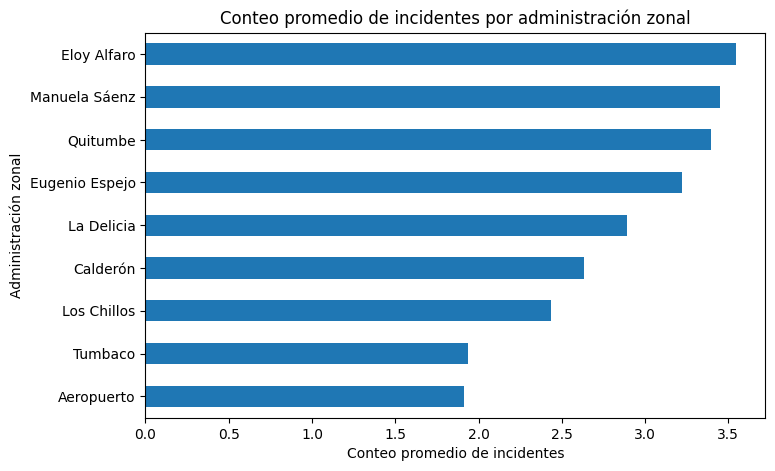

In [12]:
 # ============================================================
# 13. Visualizaciones básicas
# ============================================================

# Incidentes promedio por zona
df_limpio.groupby("administracion_zonal")["conteo_incidentes"].mean().sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Conteo promedio de incidentes por administración zonal"
)

plt.xlabel("Conteo promedio de incidentes")
plt.ylabel("Administración zonal")
plt.show()

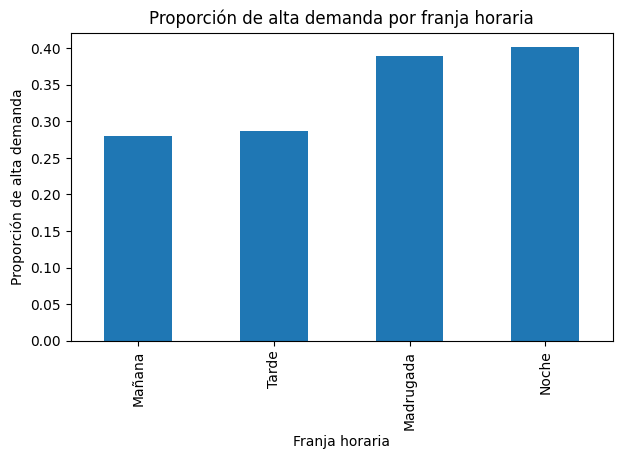

In [13]:
# Alta demanda por franja horaria

df_limpio.groupby("franja_horaria")["alta_demanda"].mean().sort_values().plot(
    kind="bar",
    figsize=(7, 4),
    title="Proporción de alta demanda por franja horaria"
)

plt.xlabel("Franja horaria")
plt.ylabel("Proporción de alta demanda")
plt.show()

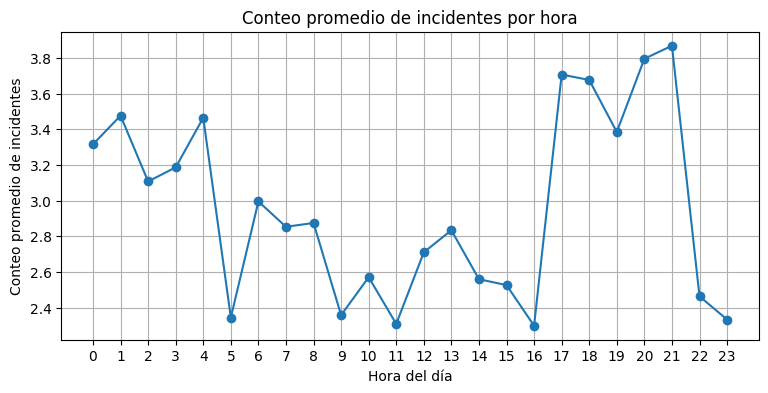

In [14]:
# Conteo promedio por hora

df_limpio.groupby("hora")["conteo_incidentes"].mean().plot(
    kind="line",
    marker="o",
    figsize=(9, 4),
    title="Conteo promedio de incidentes por hora"
)

plt.xlabel("Hora del día")
plt.ylabel("Conteo promedio de incidentes")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [15]:
# ============================================================
# 14. Variables para modelado
# ============================================================
# IMPORTANTE:
# conteo_incidentes NO debe usarse como predictor porque se usó para crear alta_demanda.
# intensidad_esperada tampoco debería usarse, porque es parte interna de la simulación.

variables_predictoras = [
    "mes",
    "dia_semana",
    "hora",
    "franja_horaria",
    "es_fin_semana",
    "es_feriado",
    "administracion_zonal",
    "tipo_incidente"
]

variable_objetivo = "alta_demanda"

X = df_limpio[variables_predictoras]
y = df_limpio[variable_objetivo]

display(X.head())
display(y.head())

,mes,dia_semana,hora,franja_horaria,es_fin_semana,es_feriado,administracion_zonal,tipo_incidente
0,4,domingo,23,Noche,1,0,Manuela Sáenz,Robo de vehículos
1,12,lunes,9,Mañana,0,0,Los Chillos,Emergencia comunitaria
2,9,domingo,6,Mañana,1,0,Quitumbe,Emergencia comunitaria
3,4,jueves,16,Tarde,0,0,Eloy Alfaro,Incidente de tránsito
4,3,jueves,3,Madrugada,0,0,Los Chillos,Robo a personas


,alta_demanda
0,0
1,0
2,0
3,0
4,0


In [16]:
# ============================================================
# 15. Exportar dataset crudo, limpio y diccionario de datos
# ============================================================

df_limpio.to_csv("seguridad_ciudadana_quito_limpio.csv", index=False)

diccionario_datos = pd.DataFrame({
    "variable": [
        "id_registro",
        "fecha",
        "mes",
        "dia_semana",
        "dia_semana_num",
        "hora",
        "franja_horaria",
        "es_fin_semana",
        "es_feriado",
        "administracion_zonal",
        "tipo_incidente",
        "intensidad_esperada",
        "conteo_incidentes",
        "alta_demanda"
    ],
    "descripcion": [
        "Identificador único del registro sintético.",
        "Fecha del bloque de observación.",
        "Mes derivado de la fecha.",
        "Día de la semana en texto.",
        "Día de la semana en formato numérico, donde lunes es 0 y domingo es 6.",
        "Hora del día del bloque de observación.",
        "Agrupación de la hora en madrugada, mañana, tarde o noche.",
        "Indica si el bloque corresponde a sábado o domingo.",
        "Indica si la fecha corresponde a un feriado simulado.",
        "Administración zonal ficticia/agregada del Distrito Metropolitano de Quito.",
        "Categoría del incidente de seguridad ciudadana.",
        "Valor interno usado para simular el conteo de incidentes.",
        "Número sintético de incidentes en el bloque.",
        "Variable objetivo: 1 si el bloque es de alta demanda, 0 caso contrario."
    ],
    "uso_modelo": [
        "No usar",
        "No usar directamente",
        "Predictora",
        "Predictora",
        "Opcional",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "No usar",
        "No usar como predictor",
        "Variable objetivo"
    ]
})

diccionario_datos.to_csv("diccionario_datos_seguridad_ciudadana.csv", index=False)

print("Archivos exportados correctamente:")
print("- seguridad_ciudadana_quito_crudo.csv")
print("- seguridad_ciudadana_quito_limpio.csv")
print("- diccionario_datos_seguridad_ciudadana.csv")

Archivos exportados correctamente:
- seguridad_ciudadana_quito_crudo.csv
- seguridad_ciudadana_quito_limpio.csv
- diccionario_datos_seguridad_ciudadana.csv


In [17]:
from google.colab import files

files.download("seguridad_ciudadana_quito_limpio.csv")
files.download("diccionario_datos_seguridad_ciudadana.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>